# Pipeline Project

You will be using the provided data to create a machine learning model pipeline.

You must handle the data appropriately in your pipeline to predict whether an
item is recommended by a customer based on their review.
Note the data includes numerical, categorical, and text data.

You should ensure you properly train and evaluate your model.

## The Data

The dataset has been anonymized and cleaned of missing values.

There are 8 features for to use to predict whether a customer recommends or does
not recommend a product.
The `Recommended IND` column gives whether a customer recommends the product
where `1` is recommended and a `0` is not recommended.
This is your model's target/

The features can be summarized as the following:

- **Clothing ID**: Integer Categorical variable that refers to the specific piece being reviewed.
- **Age**: Positive Integer variable of the reviewers age.
- **Title**: String variable for the title of the review.
- **Review Text**: String variable for the review body.
- **Positive Feedback Count**: Positive Integer documenting the number of other customers who found this review positive.
- **Division Name**: Categorical name of the product high level division.
- **Department Name**: Categorical name of the product department name.
- **Class Name**: Categorical name of the product class name.

The target:
- **Recommended IND**: Binary variable stating where the customer recommends the product where 1 is recommended, 0 is not recommended.

## Load Data

In [1]:
# Download spacy
!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 87.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
# Load the spaCy language model
import spacy
nlp = spacy.load('en_core_web_sm')

In [3]:
import pandas as pd
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, accuracy_score

In [4]:
import pandas as pd

# Load data
df = pd.read_csv(
    'reviews.csv',
)

df.info()
df.head()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              18442 non-null  int64 
 1   Age                      18442 non-null  int64 
 2   Title                    18442 non-null  object
 3   Review Text              18442 non-null  object
 4   Positive Feedback Count  18442 non-null  int64 
 5   Division Name            18442 non-null  object
 6   Department Name          18442 non-null  object
 7   Class Name               18442 non-null  object
 8   Recommended IND          18442 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.3+ MB


,0
Clothing ID,0
Age,0
Title,0
Review Text,0
Positive Feedback Count,0
Division Name,0
Department Name,0
Class Name,0
Recommended IND,0


## Preparing features (`X`) & target (`y`)

In [5]:
data = df

# separate features from labels
X = data.drop('Recommended IND', axis=1)
y = data['Recommended IND'].copy()

print('Labels:', y.unique())
print('Features:')
display(X.head())

Labels: [0 1]
Features:


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits


In [6]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    shuffle=True,
    random_state=27,
)

# Your Work

## Data Exploration

In [7]:
y.value_counts()

,count
Recommended IND,
1,15053
0,3389


In [8]:
X.describe()

,Clothing ID,Age,Positive Feedback Count
count,18442.000000,18442.000000,18442.000000
mean,954.896757,43.383635,2.697484
std,141.571783,12.246264,5.942220
min,2.000000,18.000000,0.000000
25%,863.000000,34.000000,0.000000
50%,952.000000,41.000000,1.000000
75%,1078.000000,52.000000,3.000000
max,1205.000000,99.000000,122.000000


In [9]:
X.nunique()

,0
Clothing ID,531
Age,77
Title,13142
Review Text,18439
Positive Feedback Count,79
Division Name,2
Department Name,6
Class Name,14


In [10]:
num_features = ['Age', 'Positive Feedback Count']
cat_features = ['Division Name', 'Department Name', 'Class Name']
text_features = ['Review Text']

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Positive Feedback Count'}>]],
      dtype=object)

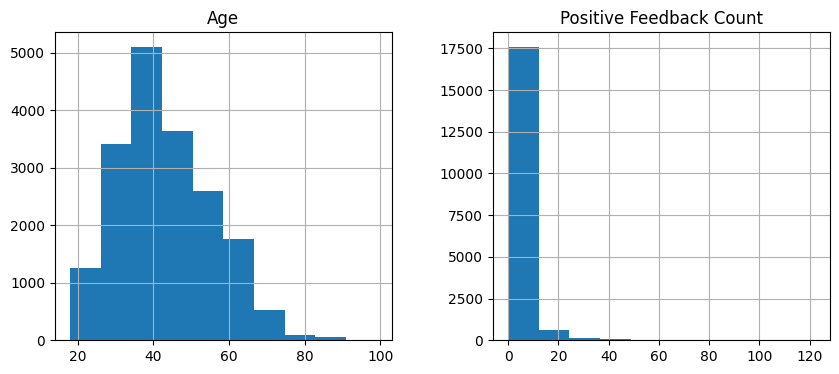

In [11]:
data[num_features].hist(figsize=(10,4))

- Dataset contains no missing values so no imputation is needed but it will be added to the pipeline
- Age follows a roughly normal distribution
- Positive Feedback Count is heavily right-skewed, needs to be transformed
- Target variable y is imbalanced

## Building Pipeline

In [12]:
# Select columns based on data type and split into numerical, categorical and text features
num_features = X[num_features].columns
print('Numerical features:', num_features)

cat_features = X[cat_features].columns
print('Categorical features:', cat_features)

text_features = X[text_features].columns
print ('Review Text features:', text_features)

Numerical features: Index(['Age', 'Positive Feedback Count'], dtype='object')
Categorical features: Index(['Division Name', 'Department Name', 'Class Name'], dtype='object')
Review Text features: Index(['Review Text'], dtype='object')


### Numerical Pipeline

In [13]:
# Define pipeline for the numerical features
num_pipeline = Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='mean'),
    ),
    (
        'scaler',
        StandardScaler(),
    ),
])

num_pipeline

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler())])

### Categorical pipeline

In [14]:
# Define pipeline for the categorical features
cat_pipeline = Pipeline([
    (
        'imputer',
        SimpleImputer(
            strategy='most_frequent',
        )
    ),
    (
        'cat_encoder',
        OneHotEncoder(
            sparse_output=False,
            handle_unknown='ignore',
        )
    ),
])
cat_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('cat_encoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

### Text Pipeline

In [15]:
from sklearn.base import BaseEstimator, TransformerMixin

# Takes in a string for the character to count
# Outputs the number times that character appears in the text
class CountCharacter(BaseEstimator, TransformerMixin):
    def __init__(self, character: str):
        self.character = character

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return [[text.count(self.character)] for text in X]

In [16]:
from sklearn.pipeline import FeatureUnion
from sklearn.preprocessing import FunctionTransformer
import numpy as np

# Pipeline for reshaping the review tex data into a 1-dimensional array
initial_text_preprocess = Pipeline([
    (
        'dimension_reshaper',
        FunctionTransformer(
            np.reshape,
            kw_args={'newshape':-1},
        ),
    ),
])

# Pipeline for counting the number of spaces, `!`, and `?` using class CountCharacter()
text_pipeline = FeatureUnion([
    ('count_spaces', CountCharacter(character=' ')),
    ('count_exclamations', CountCharacter(character='!')),
    ('count_question_marks', CountCharacter(character='?')),
])

# Combining the two pipelines to count characters in review data
character_counts_pipeline = Pipeline([
    (
        'initial_text_preprocess',
        initial_text_preprocess,
    ),
    (
        'text_pipeline',
        text_pipeline,
    ),
])
character_counts_pipeline

Pipeline(steps=[('initial_text_preprocess',
                 Pipeline(steps=[('dimension_reshaper',
                                  FunctionTransformer(func=<function reshape at 0x7f8256303930>,
                                                      kw_args={'newshape': -1}))])),
                ('text_pipeline',
                 FeatureUnion(transformer_list=[('count_spaces',
                                                 CountCharacter(character=' ')),
                                                ('count_exclamations',
                                                 CountCharacter(character='!')),
                                                ('count_question_marks',
                                                 CountCharacter(character='?'))]))])

In [17]:
# SpacyLemmatizer that removes stopwords and lemmatizes reviews
class SpacyLemmatizer(BaseEstimator, TransformerMixin):
    def __init__(self, nlp):
        self.nlp = nlp

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        lemmatized = [
            ' '.join(
                token.lemma_ for token in doc
                if not token.is_stop
            )
            for doc in self.nlp.pipe(X)
        ]
        return lemmatized

In [18]:
# Create a TF_IDF vectorizer that creates matrix of tfidf scores

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_pipeline = Pipeline([
    (
        'dimension_reshaper',
        FunctionTransformer(
            np.reshape,
            kw_args={'newshape':-1},
        ),
    ),
    (
        'lemmatizer',
        SpacyLemmatizer(nlp=nlp),
    ),
    (
        'tfidf_vectorizer',
        TfidfVectorizer(
            stop_words='english',
        ),
    ),
])
tfidf_pipeline

Pipeline(steps=[('dimension_reshaper',
                 FunctionTransformer(func=<function reshape at 0x7f8256303930>,
                                     kw_args={'newshape': -1})),
                ('lemmatizer',
                 SpacyLemmatizer(nlp=<spacy.lang.en.English object at 0x7f821a369820>)),
                ('tfidf_vectorizer', TfidfVectorizer(stop_words='english'))])

In [19]:
# Combine multiple preprocessing & nlp pipelines into a feature engineering transformer
from sklearn.compose import ColumnTransformer

feature_engineering = ColumnTransformer([
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features),
        ('character_counts', character_counts_pipeline, text_features),
        ('tfidf_text', tfidf_pipeline, text_features),
])
feature_engineering

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 Index(['Age', 'Positive Feedback Count'], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('cat_encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['Division Name', 'Departm...
                                 Index(['Review Text'], dtype='object')),
                                ('tfidf_text',
                                 Pipeline(steps=[('dimension_reshaper',
                                                  FunctionTransformer(func=<function reshape at 0x7f8256303930>,
                                                                      kw_args={'newshape': -1})),
                                                 ('lemmatizer',
                                                  SpacyLemmatizer(nlp=<spacy.lang.en.English object at 0x7f821a369820>)),
                                                 ('tfidf_vectorizer',
                                                  TfidfVectorizer(stop_words='english'))]),
                                 Index(['Review Text'], dtype='object'))])

## Training Pipeline

### Random Forest without tuning

In [20]:
# Create classification pipeline with feature_engineering transformer

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline

rf_pipeline = make_pipeline(
    feature_engineering,
    RandomForestClassifier(random_state=27),
)
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'Positive Feedback Count'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cat_encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=Fal...
                                                  Pipeline(steps=[('dimension_reshaper',
                                                                   FunctionTransformer(func=<function reshape at 0x7f8256303930>,
                                                                                       kw_args={'newshape': -1})),
                                                                  ('lemmatizer',
                                                                   SpacyLemmatizer(nlp=<spacy.lang.en.English object at 0x7f821a369820>)),
                                                                  ('tfidf_vectorizer',
                                                                   TfidfVectorizer(stop_words='english'))]),
                                                  Index(['Review Text'], dtype='object'))])),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=27))])

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluate the model
y_pred_forest_pipeline = rf_pipeline.predict(X_test)
accuracy_forest_pipeline = accuracy_score(y_test, y_pred_forest_pipeline)
precision = precision_score(y_test, y_pred_forest_pipeline)
recall = recall_score(y_test, y_pred_forest_pipeline)
f1 = f1_score(y_test, y_pred_forest_pipeline)

print('Accuracy:', accuracy_forest_pipeline)
print(f"Precision:", precision)
print(f"Recall:", recall)
print(f"F1 Score:", f1)

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Accuracy: 0.8471544715447155
Precision: 0.8491525423728814
Recall: 0.9901185770750988
F1 Score: 0.9142335766423357


- Recall being much higher is a classic sign of data imbalance

### Fine-Tuning Pipeline with RandomizedSearchCV

In [22]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'randomforestclassifier__n_estimators': randint(100, 300),
    'randomforestclassifier__max_depth': [5, 10, 20, None],
    'randomforestclassifier__max_features': ['sqrt', 'log2'],
    'randomforestclassifier__min_samples_split': randint(2, 10),
    'randomforestclassifier__class_weight': [None, 'balanced']
}

random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='f1',
    verbose=2,
    n_jobs=1,
    random_state=27
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


[CV] END randomforestclassifier__class_weight=balanced, randomforestclassifier__max_depth=5, randomforestclassifier__max_features=sqrt, randomforestclassifier__min_samples_split=9, randomforestclassifier__n_estimators=156; total time= 2.5min


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


[CV] END randomforestclassifier__class_weight=balanced, randomforestclassifier__max_depth=5, randomforestclassifier__max_features=sqrt, randomforestclassifier__min_samples_split=9, randomforestclassifier__n_estimators=156; total time= 2.5min


...

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


[CV] END randomforestclassifier__class_weight=None, randomforestclassifier__max_depth=None, randomforestclassifier__max_features=sqrt, randomforestclassifier__min_samples_split=5, randomforestclassifier__n_estimators=279; total time= 3.0min


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


[CV] END randomforestclassifier__class_weight=None, randomforestclassifier__max_depth=None, randomforestclassifier__max_features=sqrt, randomforestclassifier__min_samples_split=5, randomforestclassifier__n_estimators=279; total time= 3.0min


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('columntransformer',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer()),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               Index(['Age', 'Positive Feedback Count'], dtype='object')),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('cat_encoder',
                                                                                                OneHotEncoder(handle_...
                                        'randomforestclassifier__max_depth': [5,
                                                                              10,
                                                                              20,
                                                                              None],
                                        'randomforestclassifier__max_features': ['sqrt',
                                                                                 'log2'],
                                        'randomforestclassifier__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f81feff7ad0>,
                                        'randomforestclassifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f81fffc9dc0>},
                   random_state=27, scoring='f1', verbose=2)

In [23]:
# retrieve the best parameters
random_search.best_params_

{'randomforestclassifier__class_weight': 'balanced',
 'randomforestclassifier__max_depth': None,
 'randomforestclassifier__max_features': 'sqrt',
 'randomforestclassifier__min_samples_split': 7,
 'randomforestclassifier__n_estimators': 133}

In [24]:
# retrieve the best model
best_pipeline = random_search.best_estimator_
best_pipeline

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'Positive Feedback Count'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cat_encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=Fal...
                                                                   FunctionTransformer(func=<function reshape at 0x7f8256303930>,
                                                                                       kw_args={'newshape': -1})),
                                                                  ('lemmatizer',
                                                                   SpacyLemmatizer(nlp=<spacy.lang.en.English object at 0x7f81fafbb3b0>)),
                                                                  ('tfidf_vectorizer',
                                                                   TfidfVectorizer(stop_words='english'))]),
                                                  Index(['Review Text'], dtype='object'))])),
                ('randomforestclassifier',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_split=7, n_estimators=133,
                                        random_state=27))])

In [25]:
# calculate the final metrics of the best model
y_pred_forest_best = best_pipeline.predict(X_test)
accuracy_forest_best = accuracy_score(y_test, y_pred_forest_best)

precision_best = precision_score(y_test, y_pred_forest_best)
recall_best = recall_score(y_test, y_pred_forest_best)
f1_best = f1_score(y_test, y_pred_forest_best)

print('Final accuracy:', accuracy_forest_best)
print(f"Final precision:", precision_best)
print(f"Final recall:", recall_best)
print(f"Final f1 score:", f1_best)

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Final accuracy: 0.867750677506775
Final precision: 0.8760330578512396
Final recall: 0.9776021080368906
Final f1 score: 0.9240348692403487


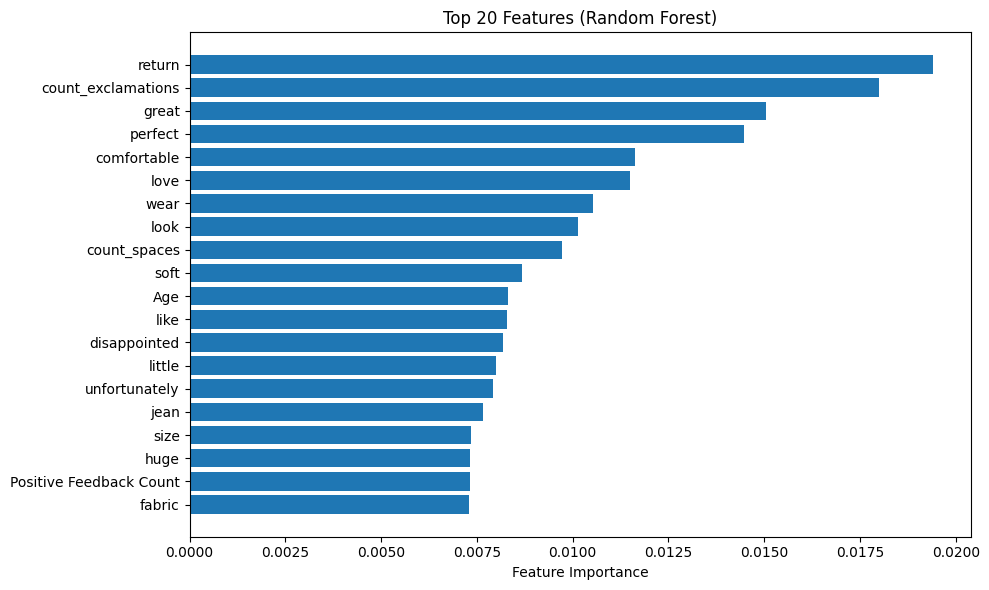

                feature  importance
                 return    0.019415
     count_exclamations    0.018006
                  great    0.015051
                perfect    0.014467
            comfortable    0.011619
                   love    0.011495
                   wear    0.010523
                   look    0.010134
           count_spaces    0.009716
                   soft    0.008675
                    Age    0.008307
                   like    0.008284
           disappointed    0.008175
                 little    0.007985
          unfortunately    0.007910
                   jean    0.007660
                   size    0.007351
                   huge    0.007328
Positive Feedback Count    0.007316
                 fabric    0.007289


In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Get the best pipeline and extract the feature engineering step
best_pipeline = random_search.best_estimator_
ct = best_pipeline.named_steps['columntransformer']
rf = best_pipeline.named_steps['randomforestclassifier']

# Get feature names from each transformer
num_names = list(num_features)
cat_names = list(ct.named_transformers_['cat'].named_steps['cat_encoder'].get_feature_names_out(cat_features))
char_names = ['count_spaces', 'count_exclamations', 'count_question_marks']
tfidf_names = list(ct.named_transformers_['tfidf_text'].named_steps['tfidf_vectorizer'].get_feature_names_out())

all_feature_names = num_names + cat_names + char_names + tfidf_names

# Build importance dataframe
feature_importances = pd.DataFrame({
    'feature': all_feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

# Show top 20
top_n = 20
plt.figure(figsize=(10, 6))
plt.barh(
    feature_importances['feature'].head(top_n)[::-1],
    feature_importances['importance'].head(top_n)[::-1],
)
plt.xlabel('Feature Importance')
plt.title(f'Top {top_n} Features (Random Forest)')
plt.tight_layout()
plt.show()

print(feature_importances.head(top_n).to_string(index=False))

- Model performance improved as expected with RandomizedSearchCV
- The model performed better with class weight set to balanced, dataset was imbalanced
- Recall is still high
- The "Return" Signal is the top Feature. The moment a customer mentions returning an item, the probability of a "Recommended IND = 1" becomes low as expected.
- count_exclamations is the #2 feature.
- Words like "great", "perfect", "comfortable", and "soft" all rank highly. This suggests that for this specific clothing brand, tactile comfort is a primary driver of recommendations.


### Best Model with NER and POS tagging

In [27]:
# Define the Advanced Feature Extractor
class SpacyNumericFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, nlp):
        self.nlp = nlp

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        pos_features = []
        ner_features = []
        for doc in self.nlp.pipe(X, batch_size=50):
            counts = {"NOUN": 0, "VERB": 0, "ADJ": 0}
            for token in doc:
                if token.pos_ in counts:
                    counts[token.pos_] += 1
            total = len(doc) + 1e-6
            pos_features.append([counts["NOUN"]/total, counts["VERB"]/total, counts["ADJ"]/total])
            ner_features.append([len(doc.ents)])
        return np.hstack([np.array(pos_features), np.array(ner_features)])

# Build the specific Sub-Pipeline
spacy_numeric_pipeline = Pipeline([
    ('dimension_reshaper', FunctionTransformer(np.reshape, kw_args={'newshape':-1})),
    ('spacy_features', SpacyNumericFeatures(nlp=nlp)),
    ('scaler', StandardScaler())
])

In [28]:
# Update the Master Feature Engineering
feature_engineering_advanced = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features),
    ('character_counts', character_counts_pipeline, text_features),
    ('nlp_density_ner', spacy_numeric_pipeline, text_features), # NEW
    ('tfidf_text', tfidf_pipeline, text_features),
])

# Initialize with the "Best" parameters
final_rf_model = RandomForestClassifier(
    n_estimators=133,
    max_depth=None,
    max_features='sqrt',
    min_samples_split=7,
    class_weight='balanced',
    random_state=27
)

In [29]:
# Create and Fit the Final Pipeline
advanced_pipeline = make_pipeline(feature_engineering_advanced, final_rf_model)
advanced_pipeline.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'Positive Feedback Count'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cat_encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=Fal...
                                                                   FunctionTransformer(func=<function reshape at 0x7f8256303930>,
                                                                                       kw_args={'newshape': -1})),
                                                                  ('lemmatizer',
                                                                   SpacyLemmatizer(nlp=<spacy.lang.en.English object at 0x7f821a369820>)),
                                                                  ('tfidf_vectorizer',
                                                                   TfidfVectorizer(stop_words='english'))]),
                                                  Index(['Review Text'], dtype='object'))])),
                ('randomforestclassifier',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_split=7, n_estimators=133,
                                        random_state=27))])

In [30]:
# Evaluation
y_pred_advanced = advanced_pipeline.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_advanced)}")
print(f"Precision: {precision_score(y_test, y_pred_advanced)}")
print(f"Recall: {recall_score(y_test, y_pred_advanced)}")
print(f"F1 Score: {f1_score(y_test, y_pred_advanced)}")

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Accuracy: 0.8579945799457994
Precision: 0.867251461988304
Recall: 0.9769433465085638
F1 Score: 0.9188351920693928


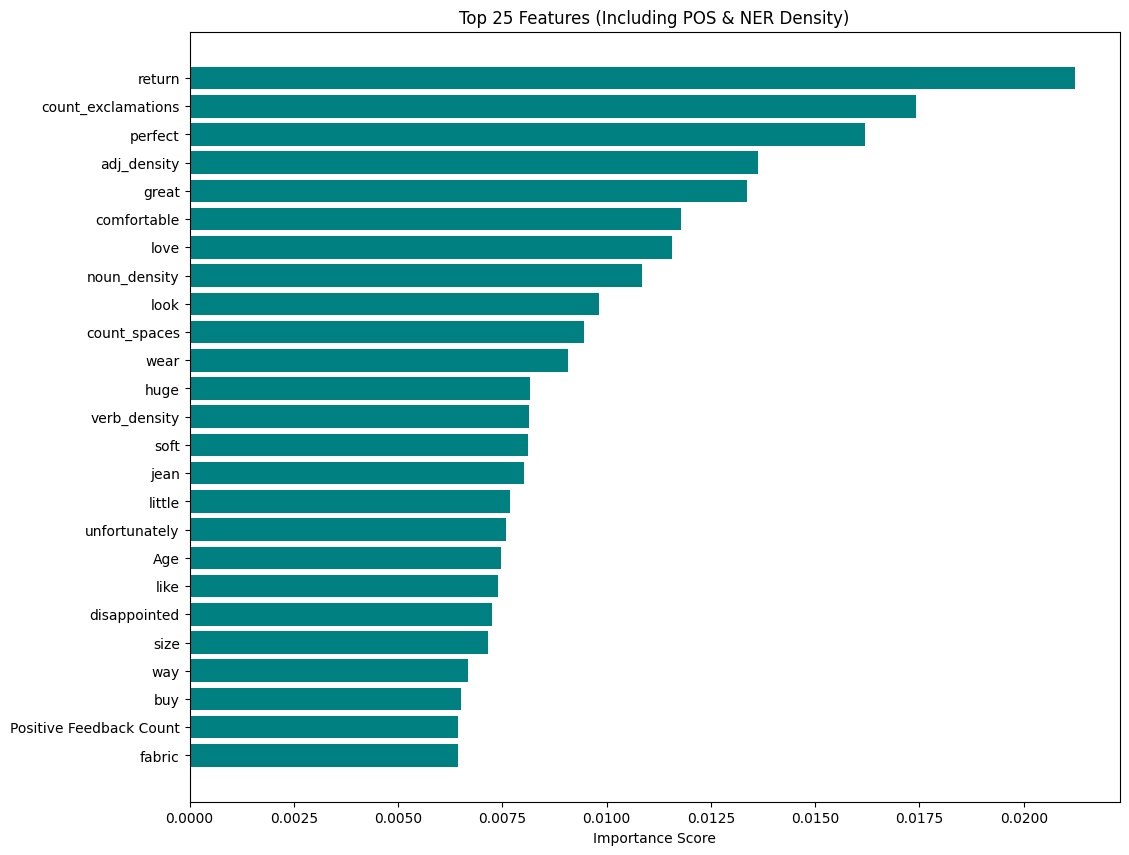

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Get the fitted ColumnTransformer
best_fe = advanced_pipeline.named_steps['columntransformer']

# 2. Extract names from each transformer branch
names_num = list(num_features)

# Categorical (OneHot)
names_cat = best_fe.named_transformers_['cat'].named_steps['cat_encoder'].get_feature_names_out(cat_features).tolist()

# Character counts (from your character_counts_pipeline)
names_char = ['count_spaces', 'count_exclamations', 'count_question_marks']

# NEW: Advanced NLP features (the ones you just added!)
# Note: These must match the order in your SpacyNumericFeatures.transform hstack
names_nlp_advanced = ['noun_density', 'verb_density', 'adj_density', 'ner_count']

# TF-IDF words
names_tfidf = best_fe.named_transformers_['tfidf_text'].named_steps['tfidf_vectorizer'].get_feature_names_out().tolist()

# 3. Combine all into one master list
all_feature_names = names_num + names_cat + names_char + names_nlp_advanced + names_tfidf

# 4. Get importances from the Random Forest
importances = advanced_pipeline.named_steps['randomforestclassifier'].feature_importances_

# 5. Create DataFrame and plot
feat_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# Plot the Top 25 to see if your new features made the cut
plt.figure(figsize=(12, 10))
plt.barh(feat_imp_df['Feature'].head(25), feat_imp_df['Importance'].head(25), color='teal')
plt.gca().invert_yaxis()
plt.title('Top 25 Features (Including POS & NER Density)')
plt.xlabel('Importance Score')
plt.show()

- f1 dipped slightly.
- adj_density, noun_density, and verb_density all made it into the Top 15. This proves that the grammatical structure of the review is a massive predictor.
- The model may be better at generalizing